# 01. 데이터 분석

공공 음식 데이터의 구조를 파악한다.

- 컬럼 구성 및 데이터 타입 확인
- 결측치 현황 파악
- 주요 컬럼의 값 분포 확인
- 추천에 활용 가능한 컬럼 후보 정리

입력: `data/raw/` / 출력: 없음 (탐색 결과 기록)

이 단계에서는 원본 데이터를 수정하거나 새로운 파일을 생성하지 않는다. 결측치, 중복, 컬럼 제거는 모두 다음 전처리 단계에서 결정한다.

## 기본 설정

In [1]:
import sys
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib import font_manager

PROJECT_ROOT = Path.cwd().parent
DATA_DIR = PROJECT_ROOT / "data"
RAW_DIR = DATA_DIR / "raw"
sys.path.append(str(PROJECT_ROOT))

pd.set_option("display.max_columns", 60)
pd.set_option("display.max_rows", 100)
pd.set_option("display.width", 200)

# 한글 폰트 설정 (설치된 폰트 중 첫 번째 사용)
_fonts = {f.name for f in font_manager.fontManager.ttflist}
for _name in ["AppleGothic", "NanumGothic", "Malgun Gothic"]:
    if _name in _fonts:
        plt.rcParams["font.family"] = _name
        break
plt.rcParams["axes.unicode_minus"] = False

## 1. 원본 CSV 확인 및 불러오기

`data/raw/`에 어떤 파일이 있는지 확인하고 CSV를 불러온다.

공공데이터포털 CSV는 UTF-8 BOM으로 저장되는 경우가 많아 `utf-8-sig`로 읽는다.

In [2]:
raw_files = sorted(RAW_DIR.glob("*.csv"))
for f in raw_files:
    print(f"{f.name}  ({f.stat().st_size / 1024 / 1024:.1f} MB)")

food_nutrition.csv  (6.7 MB)


In [3]:
RAW_PATH = RAW_DIR / "food_nutrition.csv"

df = pd.read_csv(RAW_PATH, encoding="utf-8-sig", low_memory=False)
df.shape

(19617, 50)

## 2. 데이터 크기 확인

전체 행과 컬럼 수를 확인해 데이터셋 규모를 파악한다.

In [4]:
print(f"행 개수: {df.shape[0]:,}")
print(f"컬럼 개수: {df.shape[1]}")

행 개수: 19,617
컬럼 개수: 50


## 3. 컬럼명과 데이터 타입 확인

각 컬럼이 문자열인지 숫자인지 확인한다. 숫자로 기대되는 컬럼이 문자열로 읽혔다면 전처리에서 변환이 필요하다.

In [5]:
dtype_table = pd.DataFrame({
    "dtype": df.dtypes.astype(str),
    "non_null": df.notna().sum(),
    "n_unique": df.nunique(),
})
dtype_table

,dtype,non_null,n_unique
식품코드,str,19617,19617
식품명,str,19617,15647
데이터구분코드,str,19617,1
데이터구분명,str,19617,1
식품기원코드,int64,19617,7
식품기원명,str,19617,7
식품대분류코드,int64,19617,25
식품대분류명,str,19617,25
대표식품코드,int64,19617,1237
대표식품명,str,19617,1249


In [6]:
dtype_table["dtype"].value_counts()

dtype
float64    24
str        17
int64       9
Name: count, dtype: int64

## 4. 상위 데이터 확인

실제 값의 형태를 확인한다. 컬럼이 많아 가로로 보기 어려우므로 전치해서 출력한다.

In [7]:
df.head(5).T

,0,1,2,3,4
식품코드,D504-212000000-0001,D604-212000000-0001,D704-212000000-0001,D104-198000000-0001,D404-198000000-0001
식품명,흰죽,흰죽,흰죽,흑임자죽,흑임자 죽
데이터구분코드,D,D,D,D,D
데이터구분명,음식,음식,음식,음식,음식
식품기원코드,5,6,7,1,4
식품기원명,초등학교급식(재료량 기반 산출 함량),중고등학교급식(재료량 기반 산출함량),산업체급식(재료량 기반 산출 함량),가정식(분석 함량),외식(재료량 기반 산출함량)
식품대분류코드,4,4,4,4,4
식품대분류명,죽 및 스프류,죽 및 스프류,죽 및 스프류,죽 및 스프류,죽 및 스프류
대표식품코드,4212,4212,4212,4198,4198
대표식품명,흰죽,흰죽,흰죽,흑임자죽,흑임자 죽


## 5. 컬럼별 결측치 확인

결측치 개수와 비율을 계산해 어떤 컬럼이 실질적으로 사용 가능한지 파악한다.

In [8]:
missing = pd.DataFrame({
    "missing_count": df.isna().sum(),
    "missing_ratio": (df.isna().mean() * 100).round(2),
})
missing = missing[missing["missing_count"] > 0].sort_values("missing_ratio", ascending=False)
print(f"결측치가 있는 컬럼: {len(missing)} / {df.shape[1]}")
missing

결측치가 있는 컬럼: 24 / 50


,missing_count,missing_ratio
1인(회)분량 참고량,19617,100.00
회분(g),18405,93.82
트랜스지방산(g),16793,85.60
비타민 A(μg RAE),15554,79.29
비타민 D(μg),15547,79.25
니아신(mg),15348,78.24
식이섬유(g),15278,77.88
베타카로틴(μg),15270,77.84
철(mg),15267,77.83
티아민(mg),15267,77.83


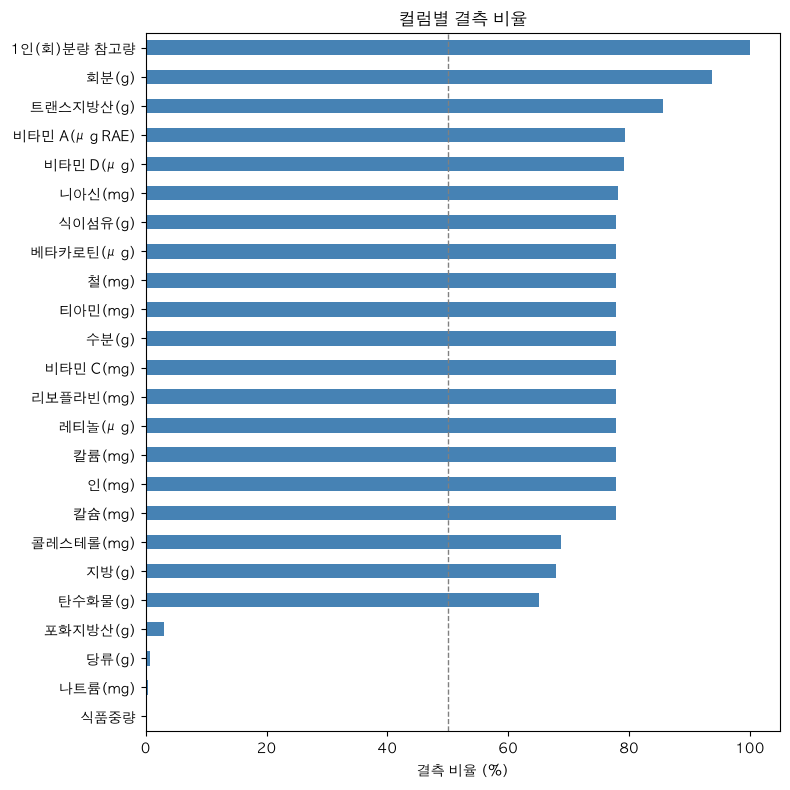

In [9]:
# 결측 비율이 컬럼별로 어떻게 갈리는지 시각화
fig, ax = plt.subplots(figsize=(8, 8))
missing["missing_ratio"].sort_values().plot.barh(ax=ax, color="steelblue")
ax.set_xlabel("결측 비율 (%)")
ax.set_title("컬럼별 결측 비율")
ax.axvline(50, color="gray", linestyle="--", linewidth=1)
plt.tight_layout()
plt.show()

### 결측치가 데이터 출처와 관련이 있는지 확인

결측 비율이 75% 전후에 몰려 있는 컬럼이 많다. 특정 출처(식품기원)의 데이터에서 일괄적으로 비어 있는지 확인한다.

In [10]:
nutrition_cols = [c for c in df.columns if "(" in c and c != "1인(회)분량 참고량"]

missing_by_origin = (
    df.groupby("식품기원명")[nutrition_cols]
    .apply(lambda g: g.isna().mean() * 100)
    .round(1)
    .T
)
missing_by_origin

식품기원명,가정식(분석 함량),산업체급식(재료량 기반 산출 함량),외식(분석함량),외식(재료량 기반 산출함량),외식(프랜차이즈 등 업체 제공 영양정보),중고등학교급식(재료량 기반 산출함량),초등학교급식(재료량 기반 산출 함량)
에너지(kcal),0.0,0.0,0.0,0.0,0.0,0.0,0.0
수분(g),0.0,0.0,5.2,0.0,100.0,0.0,0.0
단백질(g),0.0,0.0,0.0,0.0,0.0,0.0,0.0
지방(g),0.0,0.0,2.5,0.0,87.4,0.0,0.0
회분(g),0.0,100.0,5.2,100.0,100.0,100.0,100.0
탄수화물(g),0.0,0.0,2.5,0.0,83.8,0.0,0.0
당류(g),0.0,0.0,2.6,0.0,0.8,0.0,0.0
식이섬유(g),0.0,0.0,7.1,0.0,100.0,0.0,0.0
칼슘(mg),0.0,0.0,5.2,0.0,100.0,0.0,0.0
철(mg),0.0,0.0,5.5,0.0,100.0,0.0,0.0


In [11]:
df["식품기원명"].value_counts()

식품기원명
외식(프랜차이즈 등 업체 제공 영양정보)    15225
외식(재료량 기반 산출함량)            1008
산업체급식(재료량 기반 산출 함량)         789
외식(분석함량)                    770
초등학교급식(재료량 기반 산출 함량)        725
중고등학교급식(재료량 기반 산출함량)        618
가정식(분석 함량)                  482
Name: count, dtype: int64

## 6. 완전히 중복된 행 확인

모든 컬럼 값이 동일한 행이 있는지 확인한다.

In [12]:
full_dup = df.duplicated().sum()
print(f"완전 중복 행: {full_dup:,}")
print(f"식품코드 고유값: {df['식품코드'].nunique():,} / {len(df):,}")

완전 중복 행: 0
식품코드 고유값: 19,617 / 19,617


## 7. 음식명 컬럼 확인

음식명에 해당하는 컬럼은 `식품명`이다. `대표식품명`은 세부 메뉴를 묶는 상위 이름으로 보인다.

같은 음식명이 여러 행에 나타나는지, 그렇다면 무엇이 다른지 확인한다.

In [13]:
name_counts = df["식품명"].value_counts()

print(f"고유 식품명: {df['식품명'].nunique():,} / {len(df):,}")
print(f"2회 이상 등장하는 식품명: {(name_counts > 1).sum():,}")
print(f"중복으로 인한 초과 행: {len(df) - df['식품명'].nunique():,}")

고유 식품명: 15,647 / 19,617
2회 이상 등장하는 식품명: 1,737
중복으로 인한 초과 행: 3,970


In [14]:
# 식품명별 등장 횟수 분포
name_counts.value_counts().sort_index().rename_axis("등장 횟수").rename("식품명 수")

등장 횟수
1     13910
2       780
3       368
4       310
5       160
6        51
7        19
8        13
9         7
10        4
11        5
12        4
13        6
14        1
15        1
16        2
17        1
18        1
20        4
Name: 식품명 수, dtype: int64

In [15]:
name_counts.head(15)

식품명
커피_카페 라떼 핫(HOT)       20
커피_카페 라떼 아이스(ICED)    20
커피_아메리카노 핫(HOT)       20
커피_아메리카노 아이스(ICED)    20
커피_카페모카 아이스(ICED)     18
에이드_자몽 에이드            17
커피_카페모카 핫(HOT)        16
베이글_플레인 베이글           16
에이드_레몬 에이드            15
피자_치즈 피자 (L)          14
피자_페퍼로니 피자 (L)        13
피자_불고기 피자 (L)         13
커피_바닐라 라떼 핫(HOT)      13
샌드위치_크로크무슈            13
베이글_어니언 베이글           13
Name: count, dtype: int64

### 음식명이 같은 행은 무엇이 다른가

가장 많이 중복된 음식명 하나를 골라 실제 행을 비교한다.

In [16]:
sample_name = name_counts.index[0]
df[df["식품명"] == sample_name][
    ["식품명", "식품기원명", "업체명", "영양성분함량기준량", "식품중량", "에너지(kcal)", "나트륨(mg)"]
]

,식품명,식품기원명,업체명,영양성분함량기준량,식품중량,에너지(kcal),나트륨(mg)
7581,커피_카페 라떼 핫(HOT),외식(프랜차이즈 등 업체 제공 영양정보),베러댄와플,100g,240g,58,43.0
7582,커피_카페 라떼 핫(HOT),외식(프랜차이즈 등 업체 제공 영양정보),매머드 익스프레스,100g,473g,46,34.0
7583,커피_카페 라떼 핫(HOT),외식(프랜차이즈 등 업체 제공 영양정보),더벤티,100g,591g,44,30.0
7584,커피_카페 라떼 핫(HOT),외식(프랜차이즈 등 업체 제공 영양정보),탐앤탐스,100g,310g,59,45.0
7585,커피_카페 라떼 핫(HOT),외식(프랜차이즈 등 업체 제공 영양정보),토프레소,100g,385g,32,27.0
7586,커피_카페 라떼 핫(HOT),외식(프랜차이즈 등 업체 제공 영양정보),커피에반하다,100g,355g,43,31.0
7587,커피_카페 라떼 핫(HOT),외식(프랜차이즈 등 업체 제공 영양정보),할리스,100ml,354ml,47,37.0
7588,커피_카페 라떼 핫(HOT),외식(프랜차이즈 등 업체 제공 영양정보),블루샥,100ml,473ml,41,26.0
7589,커피_카페 라떼 핫(HOT),외식(프랜차이즈 등 업체 제공 영양정보),메가커피,100ml,591ml,30,17.0
7590,커피_카페 라떼 핫(HOT),외식(프랜차이즈 등 업체 제공 영양정보),카페띠아모,100g,250g,60,41.0


In [17]:
# 급식 데이터 예시: 동일 음식이 급식 종류별로 반복되는지 확인
df[df["식품명"] == "흰죽"][
    ["식품명", "식품기원명", "업체명", "영양성분함량기준량", "식품중량", "에너지(kcal)"]
]

,식품명,식품기원명,업체명,영양성분함량기준량,식품중량,에너지(kcal)
0,흰죽,초등학교급식(재료량 기반 산출 함량),해당없음,100ml,291.90ml,64
1,흰죽,중고등학교급식(재료량 기반 산출함량),해당없음,100ml,291.90ml,64
2,흰죽,산업체급식(재료량 기반 산출 함량),해당없음,100ml,291.90ml,64


In [18]:
# 식품명 + 영양성분이 완전히 같은 행 수
dup_name_nutrition = df.duplicated(subset=["식품명"] + nutrition_cols).sum()
print(f"식품명과 영양성분이 모두 동일한 중복 행: {dup_name_nutrition:,}")

# 식품명 + 업체명 기준 중복
dup_name_company = df.duplicated(subset=["식품명", "업체명"]).sum()
print(f"식품명과 업체명이 동일한 중복 행: {dup_name_company:,}")

식품명과 영양성분이 모두 동일한 중복 행: 656
식품명과 업체명이 동일한 중복 행: 2,236


### 음식명 표기 형태

프랜차이즈 데이터의 식품명은 `카테고리_메뉴명 (사이즈)` 형태로 보인다. 어느 정도 비율인지 확인한다.

In [19]:
has_underscore = df["식품명"].str.contains("_", regex=False)
has_size = df["식품명"].str.contains(r"\((HOT|ICED|L|M|R|S|Tall|Grande|EX|ML|조각)\)", regex=True)

print(f"'_' 포함 식품명: {has_underscore.sum():,} ({has_underscore.mean() * 100:.1f}%)")
print(f"사이즈/온도 표기 포함 식품명: {has_size.sum():,} ({has_size.mean() * 100:.1f}%)")

df.loc[has_underscore, "식품명"].sample(10, random_state=0).tolist()

'_' 포함 식품명: 17,005 (86.7%)
사이즈/온도 표기 포함 식품명: 7,852 (40.0%)


/var/folders/cy/2xnr6fv10tx4ns0_r2lm0glr0000gn/T/ipykernel_59381/3846521085.py:2: UserWarning: This pattern is interpreted as a regular expression, and has match groups. To actually get the groups, use str.extract.
  has_size = df["식품명"].str.contains(r"\((HOT|ICED|L|M|R|S|Tall|Grande|EX|ML|조각)\)", regex=True)


['칼국수_해물',
 '케이크_망고요거생크림케이크',
 '허브차_페퍼민트 아이스(ICED) (L)',
 '피자_페페로니 피자 석쇠 (L)',
 '피자_위스콘신 치즈 포테이토 (F)',
 '피자_밤호박 피자 밀스크린치즈크러스트 (L)',
 '소고기 국밥_내장',
 '라떼_머스캣 밀크티 라떼 아이스(ICED) (R)',
 '커피_디카페인 콜드브루 라떼 아이스(ICED)',
 '피자_페퍼로니 스파이시 갈릭 치즈롤 (P)']

In [20]:
# '_' 앞부분(프랜차이즈 메뉴 카테고리) 상위 값
df.loc[has_underscore, "식품명"].str.split("_").str[0].value_counts().head(20)

식품명
피자         4706
커피         1825
스무디        1103
라떼          988
케이크         657
아이스크림       465
밀크티/버블티     328
버거          295
도넛          285
에이드         257
닭튀김         246
샌드위치        233
과ㆍ채주스       228
와플          199
기타차         187
마카롱         186
허브차         164
크로플         162
빙수          154
베이글         135
Name: count, dtype: int64

## 8. 음식 분류 컬럼 확인

분류 관련 컬럼은 `식품대분류명`, `대표식품명`, `식품중분류명`, `식품소분류명`, `식품세분류명`이다.

각 단계의 고유값 수와 실제 분포를 확인한다.

In [21]:
category_cols = ["식품대분류명", "대표식품명", "식품중분류명", "식품소분류명", "식품세분류명"]

pd.DataFrame({
    "n_unique": df[category_cols].nunique(),
    "해당없음 비율(%)": (df[category_cols] == "해당없음").mean().mul(100).round(1),
})

,n_unique,해당없음 비율(%)
식품대분류명,25,0.0
대표식품명,1249,0.0
식품중분류명,320,85.5
식품소분류명,70,98.9
식품세분류명,5,100.0


In [22]:
df["식품대분류명"].value_counts()

식품대분류명
빵 및 과자류         8643
음료 및 차류         5776
유제품류 및 빙과류       663
튀김류              526
국 및 탕류           513
볶음류              506
생채·무침류           501
밥류               424
면 및 만두류          344
찌개 및 전골류         340
구이류              289
나물·숙채류           248
조림류              229
전·적 및 부침류        198
찜류               177
죽 및 스프류          105
김치류               52
장류, 양념류           25
장아찌·절임류           24
젓갈류               17
수·조·어·육류           8
곡류, 서류 제품          6
채소, 해조류            1
과일류                1
두류, 견과 및 종실류       1
Name: count, dtype: int64

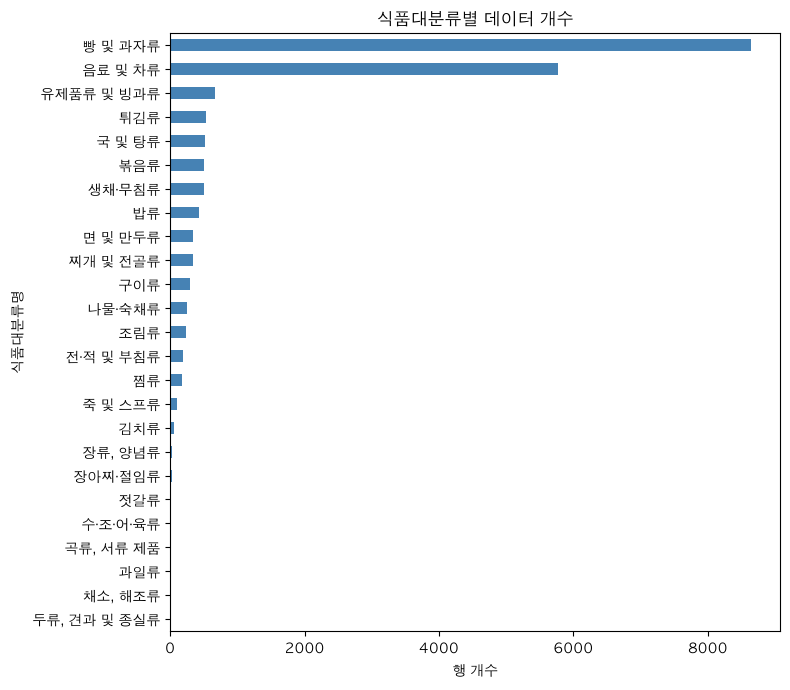

In [23]:
# 대분류별 데이터 개수 시각화
fig, ax = plt.subplots(figsize=(8, 7))
df["식품대분류명"].value_counts().sort_values().plot.barh(ax=ax, color="steelblue")
ax.set_xlabel("행 개수")
ax.set_title("식품대분류별 데이터 개수")
plt.tight_layout()
plt.show()

### 대분류와 데이터 출처의 관계

빵/과자류와 음료류가 전체의 대부분을 차지한다. 이 데이터가 어느 출처에서 왔는지 확인한다.

In [24]:
pd.crosstab(df["식품대분류명"], df["식품기원명"])

식품기원명,가정식(분석 함량),산업체급식(재료량 기반 산출 함량),외식(분석함량),외식(재료량 기반 산출함량),외식(프랜차이즈 등 업체 제공 영양정보),중고등학교급식(재료량 기반 산출함량),초등학교급식(재료량 기반 산출 함량)
식품대분류명,,,,,,,
"곡류, 서류 제품",0,1,3,1,0,1,0
과일류,0,0,0,0,1,0,0
구이류,30,44,40,75,16,41,43
국 및 탕류,54,113,48,96,1,92,109
김치류,10,4,22,7,0,5,4
나물·숙채류,26,58,8,58,0,44,54
"두류, 견과 및 종실류",0,0,0,0,1,0,0
면 및 만두류,30,49,96,66,32,33,38
밥류,51,68,58,96,18,64,69


In [25]:
df["식품중분류명"].value_counts().head(15)

식품중분류명
해당없음       16768
불고기피자        146
포테이토피자       146
카페라떼         135
치즈피자         124
아메리카노        124
페퍼로니피자       117
소고기          102
채소            82
돼지고기          72
카페모카          71
콤비네이션피자       59
카라멜마끼아토       59
그린티           58
간장            50
Name: count, dtype: int64

In [26]:
df["식품세분류명"].value_counts()

식품세분류명
해당없음         19608
양상추              6
크림(중량12g)        1
채소               1
떡                1
Name: count, dtype: int64

In [27]:
df["대표식품명"].value_counts().head(15)

대표식품명
피자         4710
커피         1825
스무디        1103
라떼          988
케이크         657
아이스크림       465
밀크티/버블티     328
버거          295
도넛          285
에이드         257
닭튀김         251
샌드위치        233
과ㆍ채주스       228
와플          199
마카롱         187
Name: count, dtype: int64

## 9. 추천에 활용 가능한 컬럼 확인

메뉴 추천 관점에서 각 컬럼이 어떤 정보를 주는지 확인한다.

### 9-1. 제공량 관련 컬럼

`영양성분함량기준량`은 영양성분 수치의 기준(100g 또는 100ml), `식품중량`은 1회 제공 총량으로 보인다. `1인(회)분량 참고량`은 별도 컬럼으로 존재한다.

In [28]:
df["영양성분함량기준량"].value_counts()

영양성분함량기준량
100g     13877
100ml     5740
Name: count, dtype: int64

In [29]:
print(f"1인(회)분량 참고량 결측: {df['1인(회)분량 참고량'].isna().sum():,} / {len(df):,}")
df["식품중량"].value_counts().head(10)

1인(회)분량 참고량 결측: 19,617 / 19,617


식품중량
100g     1069
473ml     376
591g      370
591ml     322
360ml     276
473g      274
355g      254
360g      238
710ml     207
115g      188
Name: count, dtype: int64

In [30]:
# 식품중량 단위 분포와 숫자 변환 가능 여부 확인
weight_unit = df["식품중량"].str.extract(r"([a-zA-Z]+)$")[0]
print(weight_unit.value_counts(dropna=False))

weight_value = pd.to_numeric(df["식품중량"].str.replace(r"[a-zA-Z]+$", "", regex=True), errors="coerce")
print(f"\n식품중량 숫자 변환 실패: {(weight_value.isna() & df['식품중량'].notna()).sum():,}")
weight_value.describe()

0
g      13825
ml      5740
NaN       52
Name: count, dtype: int64

식품중량 숫자 변환 실패: 0


count    19565.000000
mean       452.338950
std        344.428099
min          5.000000
25%        141.000000
50%        400.000000
75%        650.000000
max       2972.000000
Name: 식품중량, dtype: float64

### 9-2. 영양성분 컬럼

결측 비율이 낮아 대부분의 행에서 사용 가능한 영양성분과 그렇지 않은 영양성분을 구분한다.

In [31]:
nutrition_summary = pd.DataFrame({
    "missing_ratio(%)": (df[nutrition_cols].isna().mean() * 100).round(1),
    "min": df[nutrition_cols].min(),
    "median": df[nutrition_cols].median(),
    "max": df[nutrition_cols].max(),
}).sort_values("missing_ratio(%)")
nutrition_summary

,missing_ratio(%),min,median,max
에너지(kcal),0.0,0.0,165.000,1338.000
단백질(g),0.0,0.0,4.760,103.900
나트륨(mg),0.3,0.0,217.000,7518.000
당류(g),0.8,0.0,4.910,126.060
포화지방산(g),3.0,0.0,2.350,138.290
탄수화물(g),65.1,0.0,11.380,91.000
지방(g),67.9,0.0,3.310,69.060
콜레스테롤(mg),68.7,0.0,11.310,870.150
비타민 C(mg),77.8,0.0,1.270,84.510
리보플라빈(mg),77.8,0.0,0.081,5.162


In [32]:
usable_nutrition = nutrition_summary[nutrition_summary["missing_ratio(%)"] < 10].index.tolist()
sparse_nutrition = nutrition_summary[nutrition_summary["missing_ratio(%)"] >= 50].index.tolist()

print("대부분 행에서 사용 가능 (결측 10% 미만):", usable_nutrition)
print("\n절반 이상 결측:", sparse_nutrition)

대부분 행에서 사용 가능 (결측 10% 미만): ['에너지(kcal)', '단백질(g)', '나트륨(mg)', '당류(g)', '포화지방산(g)']

절반 이상 결측: ['탄수화물(g)', '지방(g)', '콜레스테롤(mg)', '비타민 C(mg)', '리보플라빈(mg)', '티아민(mg)', '베타카로틴(μg)', '레티놀(μg)', '칼륨(mg)', '인(mg)', '철(mg)', '칼슘(mg)', '수분(g)', '식이섬유(g)', '니아신(mg)', '비타민 D(μg)', '비타민 A(μg RAE)', '트랜스지방산(g)', '회분(g)']


### 9-3. 설명 및 기타 속성 컬럼

음식에 대한 텍스트 설명 컬럼이 있는지, 업체명이나 데이터 생성 방식이 추천에 쓸 만한 정보인지 확인한다.

In [33]:
text_cols = df.select_dtypes(include="object").columns.tolist()
pd.DataFrame({
    "n_unique": df[text_cols].nunique(),
    "example": df[text_cols].iloc[0],
})

/var/folders/cy/2xnr6fv10tx4ns0_r2lm0glr0000gn/T/ipykernel_59381/1737812122.py:1: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  text_cols = df.select_dtypes(include="object").columns.tolist()


,n_unique,example
식품코드,19617,D504-212000000-0001
식품명,15647,흰죽
데이터구분코드,1,D
데이터구분명,1,음식
식품기원명,7,초등학교급식(재료량 기반 산출 함량)
식품대분류명,25,죽 및 스프류
대표식품명,1249,흰죽
식품중분류명,320,해당없음
식품소분류명,70,해당없음
식품세분류명,5,해당없음


In [34]:
print(f"업체명 고유값: {df['업체명'].nunique()}")
df["업체명"].value_counts().head(10)

업체명 고유값: 145


업체명
해당없음      4144
지정환피자      824
커피에반하다     591
파파존스       528
파리바게뜨      496
뚜레쥬르       494
이디야        435
요거프레소      408
도미노피자      399
피자헛        373
Name: count, dtype: int64

In [35]:
df["데이터생성방법명"].value_counts()

데이터생성방법명
수집    15249
산출     3140
분석     1228
Name: count, dtype: int64

## 10. 행정용, 출처용, 관리용 컬럼 정리

추천 로직에 직접 쓰이지 않을 것으로 보이는 컬럼을 확인한다. 고유값이 1개인 컬럼은 정보량이 없다.

In [36]:
constant_cols = [c for c in df.columns if df[c].nunique() == 1]
print("고유값이 1개인 컬럼:", constant_cols)
for c in constant_cols:
    print(f"  {c}: {df[c].iloc[0]}")

print("\n전체 결측 컬럼:", [c for c in df.columns if df[c].isna().all()])

고유값이 1개인 컬럼: ['데이터구분코드', '데이터구분명', '데이터기준일자']
  데이터구분코드: D
  데이터구분명: 음식
  데이터기준일자: 2026-08-28

전체 결측 컬럼: ['1인(회)분량 참고량']


In [37]:
# 코드/명칭 쌍 컬럼: 코드는 명칭과 1:1 대응이므로 하나만 있어도 충분한지 확인
code_name_pairs = [
    ("데이터구분코드", "데이터구분명"),
    ("식품기원코드", "식품기원명"),
    ("식품대분류코드", "식품대분류명"),
    ("대표식품코드", "대표식품명"),
    ("식품중분류코드", "식품중분류명"),
    ("식품소분류코드", "식품소분류명"),
    ("식품세분류코드", "식품세분류명"),
    ("출처코드", "출처명"),
    ("데이터생성방법코드", "데이터생성방법명"),
]
for code_col, name_col in code_name_pairs:
    one_to_one = df.groupby(code_col)[name_col].nunique().max() == 1
    print(f"{code_col} -> {name_col}: 1:1 대응 {one_to_one}  (코드 {df[code_col].nunique()}개, 명칭 {df[name_col].nunique()}개)")

데이터구분코드 -> 데이터구분명: 1:1 대응 True  (코드 1개, 명칭 1개)
식품기원코드 -> 식품기원명: 1:1 대응 True  (코드 7개, 명칭 7개)
식품대분류코드 -> 식품대분류명: 1:1 대응 True  (코드 25개, 명칭 25개)
대표식품코드 -> 대표식품명: 1:1 대응 False  (코드 1237개, 명칭 1249개)
식품중분류코드 -> 식품중분류명: 1:1 대응 True  (코드 1924개, 명칭 320개)
식품소분류코드 -> 식품소분류명: 1:1 대응 True  (코드 2008개, 명칭 70개)
식품세분류코드 -> 식품세분류명: 1:1 대응 True  (코드 5개, 명칭 5개)
출처코드 -> 출처명: 1:1 대응 True  (코드 2개, 명칭 2개)
데이터생성방법코드 -> 데이터생성방법명: 1:1 대응 True  (코드 3개, 명칭 3개)


In [38]:
column_roles = {
    "식별자": ["식품코드"],
    "음식명": ["식품명", "대표식품명"],
    "분류": ["식품대분류명", "식품중분류명", "식품소분류명", "식품세분류명"],
    "제공량": ["영양성분함량기준량", "식품중량", "1인(회)분량 참고량"],
    "영양성분": nutrition_cols,
    "출처/데이터 성격": ["식품기원명", "업체명", "출처명", "데이터생성방법명"],
    "코드 (명칭과 중복)": [c for c, _ in code_name_pairs],
    "관리용": ["데이터구분명", "데이터생성일자", "데이터기준일자"],
}

assigned = [c for cols in column_roles.values() for c in cols]
unassigned = [c for c in df.columns if c not in assigned]
print("역할 미지정 컬럼:", unassigned)

pd.DataFrame(
    [(role, c) for role, cols in column_roles.items() for c in cols],
    columns=["역할", "컬럼"],
).groupby("역할")["컬럼"].apply(list)

역할 미지정 컬럼: []


역할
관리용                                   [데이터구분명, 데이터생성일자, 데이터기준일자]
분류                              [식품대분류명, 식품중분류명, 식품소분류명, 식품세분류명]
식별자                                                       [식품코드]
영양성분           [에너지(kcal), 수분(g), 단백질(g), 지방(g), 회분(g), 탄수화물(...
음식명                                                 [식품명, 대표식품명]
제공량                               [영양성분함량기준량, 식품중량, 1인(회)분량 참고량]
출처/데이터 성격                            [식품기원명, 업체명, 출처명, 데이터생성방법명]
코드 (명칭과 중복)    [데이터구분코드, 식품기원코드, 식품대분류코드, 대표식품코드, 식품중분류코드, 식품...
Name: 컬럼, dtype: object

## 분석 결과

### 데이터셋 전체 규모

- 파일: `data/raw/food_nutrition.csv` (식품의약품안전처 음식 영양성분 데이터)
- 19,617행, 50컬럼
- `데이터구분명`은 모두 `음식`이며, 원재료가 아닌 조리된 음식 단위 데이터

### 주요 컬럼

- `식품명`: 음식명. 15,647개 고유값
- `식품대분류명`: 25개 분류 (국 및 탕류, 볶음류, 빵 및 과자류 등). 결측 없음
- `대표식품명`: 세부 메뉴를 묶는 상위 이름. 1,249개 고유값
- `식품기원명`: 데이터 출처 성격 (가정식, 급식, 외식, 프랜차이즈). 7개
- `업체명`: 프랜차이즈 브랜드명. 145개, 비프랜차이즈는 `해당없음`
- 영양성분 컬럼 24개, 기준량은 `영양성분함량기준량`(100g 또는 100ml)
- `식품중량`: 1회 제공 총량으로 추정 (예: `291.90ml`)

### 결측치가 많은 컬럼

- `1인(회)분량 참고량`: 100% 결측. 사용 불가
- 트랜스지방산 85.6%, 회분 93.8% 결측
- 수분, 식이섬유, 칼슘, 철, 인, 칼륨, 비타민류, 콜레스테롤 등 미량영양소 대부분: 68~79% 결측
- 결측은 출처와 강하게 연결됨. `외식(프랜차이즈 등 업체 제공 영양정보)` 15,225행은 미량영양소가 전부 결측이며, 급식과 가정식 데이터는 결측이 거의 없음
- 거의 모든 행에서 사용 가능한 영양성분: 에너지, 단백질, 당류, 나트륨, 포화지방산 (결측 3% 이하)

### 중복 데이터 현황

- 모든 컬럼이 동일한 완전 중복 행: 0
- `식품코드`는 전부 고유

### 음식명 중복 현황

- 식품명 기준 3,970행이 중복 (15,647개 고유값 / 19,617행)
- 중복 원인 두 가지
  - 급식 데이터: 같은 음식이 초등학교급식, 중고등학교급식, 산업체급식으로 반복되며 영양성분도 동일 (예: 흰죽 3행)
  - 프랜차이즈 데이터: 같은 메뉴명이 여러 업체에 존재하며 영양성분은 다름 (예: 아메리카노 20개 업체)
- 식품명과 영양성분이 모두 동일한 행: 656행. 이는 사실상 동일 데이터
- 프랜차이즈 식품명은 `카테고리_메뉴명 (사이즈)` 형태이며 전체의 약 87%가 `_` 접두어를 포함

### 추천에 활용할 수 있는 컬럼

- 음식명: `식품명`, `대표식품명`
- 분류: `식품대분류명`. 중분류 이하는 `해당없음` 비율이 높아 보조적으로만 사용
- 영양성분: 에너지, 단백질, 당류, 나트륨, 포화지방산은 전체 행에서 사용 가능. 지방, 탄수화물, 콜레스테롤은 비프랜차이즈 데이터에서만 사용 가능
- 제공량: `영양성분함량기준량`, `식품중량`
- 데이터 성격 구분: `식품기원명`, `업체명` (가정식/급식 메뉴와 프랜차이즈 메뉴를 구분하는 필터로 활용 가능)

### 제외를 고려할 수 있는 컬럼

- `1인(회)분량 참고량`: 전체 결측
- `데이터구분코드`, `데이터구분명`, `데이터기준일자`: 고유값 1개
- 코드 컬럼 9개 (`식품기원코드`, `식품대분류코드`, `출처코드` 등): 명칭 컬럼과 1:1 대응이므로 중복
- `출처명`, `데이터생성방법명`, `데이터생성일자`: 출처 및 관리 정보로 추천 로직에 직접 쓰이지 않음
- `식품소분류명`, `식품세분류명`: `해당없음` 비율이 높고 정보량이 적음
- 결측 85% 이상인 영양성분 (`회분`, `트랜스지방산`)

### 데이터에서 발견된 문제점

- 음식 설명 텍스트 컬럼이 없다. 자연어 추천에 쓸 텍스트는 식품명과 분류명에서 구성해야 한다
- 프랜차이즈 데이터 편중: 빵 및 과자류 8,643행, 음료 및 차류 5,776행으로 전체의 약 73%. 한식 식사류(국, 찌개, 볶음, 구이 등)는 각 200~500행 수준
- 프랜차이즈 데이터는 미량영양소가 전부 결측이라 영양 기반 필터링 시 데이터 성격에 따라 사용 가능한 컬럼이 다르다
- 식품명에 사이즈, 온도(HOT/ICED), 브랜드 카테고리 접두어가 섞여 있어 그대로 임베딩하면 노이즈가 된다
- `식품중량`이 문자열이며 단위(g, ml)가 섞여 있고 결측 52행이 있다
- 매운맛, 국물 여부, 온도, 조리법 등 자연어 추천에 핵심적인 속성이 없다. 이 정보는 LLM 라벨링 단계에서 생성해야 한다
- 급식 데이터의 동일 음식 반복(식품명 + 영양성분 동일 656행)은 추천 후보 중복으로 이어진다

### 의미가 불분명한 컬럼

- `대표식품명` / `대표식품코드`: 세부 메뉴를 묶는 상위 이름으로 보이나 공식 정의를 확인하지 못함
- `식품세분류명`: 고유값 5개로 어떤 기준의 분류인지 불분명
- `데이터생성방법명` (수집, 산출, 분석): 값의 정확한 의미와 신뢰도 차이를 확인하지 못함
- `1인(회)분량 참고량`과 `식품중량`의 관계: 전자가 전부 결측이라 후자가 1인분량인지 단정할 수 없음